# Pipeline de Dados — Bronze → Silver → Análise

**Projeto Prático — Engenharia de Dados para Machine Learning (Cibersegurança)**

Este notebook executa o pipeline completo na seguinte ordem:

1. **Camada Bronze** — Ingestão individual dos 3 datasets brutos (`incidents_master`, `financial_impact`, `market_impact`)
2. **Análise de Qualidade da Bronze** — Validações automáticas com critérios claros
3. **Camada Silver** — Left join dos 3 datasets por `incident_id`, transformações, label e remoção de leakage
4. **Análise Exploratória da Silver (EDA)** — Visualizações e estatísticas

---
**Dependências necessárias:**
```
pip install pandas pyarrow numpy matplotlib seaborn scipy scikit-learn openpyxl
```

---
# PARTE 1 — CAMADA BRONZE

Responsável por:
- Ler os 3 arquivos brutos da pasta `input/` (incidents_master, financial_impact, market_impact)
- Padronizar nomes de colunas e tipos básicos
- Salvar cada tabela em Parquet organizado por pastas
- Registrar metadados da ingestão (nome do arquivo, quantidade de linhas, hash SHA-256, data/hora da carga)

In [1]:
from __future__ import annotations

import hashlib
import re
import unicodedata
import uuid
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
except ImportError:
    stats = None

try:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import accuracy_score, f1_score, classification_report
except ImportError:
    train_test_split = LogisticRegression = Pipeline = None
    ColumnTransformer = OneHotEncoder = SimpleImputer = None
    accuracy_score = f1_score = classification_report = None

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

INPUT_DIR = Path("input")
DATA_LAKE_ROOT = Path("data_lake")

print("Ambiente configurado com sucesso.")
print(f"  Pasta de entrada : {INPUT_DIR.resolve()}")
print(f"  Data lake root   : {DATA_LAKE_ROOT.resolve()}")

Ambiente configurado com sucesso.
  Pasta de entrada : C:\Users\rafab\Downloads\projetinho\input
  Data lake root   : C:\Users\rafab\Downloads\projetinho\data_lake


## 1.1 Funções da Camada Bronze

In [ ]:
SUPPORTED_EXTENSIONS = {".csv", ".json", ".parquet", ".xlsx", ".xls"}

DATE_FORMAT_CANDIDATES = [
    "%Y-%m-%d", "%Y/%m/%d", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y",
    "%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S", "%Y/%m/%d %H:%M:%S",
]


def normalize_column_name(name: str) -> str:
    """Remove acentos, espaços e caracteres especiais do nome da coluna."""
    text = unicodedata.normalize("NFKD", str(name))
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = text.lower().strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^a-z0-9_]", "", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "coluna_sem_nome"


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza nomes de todas as colunas e resolve duplicatas."""
    normalized = [normalize_column_name(col) for col in df.columns]
    seen: dict[str, int] = {}
    unique_cols: list[str] = []
    for col in normalized:
        if col not in seen:
            seen[col] = 0
            unique_cols.append(col)
        else:
            seen[col] += 1
            unique_cols.append(f"{col}_{seen[col]}")
    result = df.copy()
    result.columns = unique_cols
    return result


def best_datetime_format_bronze(non_null: pd.Series) -> tuple[str | None, float]:
    """Tenta encontrar o melhor formato de data para uma série."""
    best_format: str | None = None
    best_ratio = 0.0
    for fmt in DATE_FORMAT_CANDIDATES:
        parsed = pd.to_datetime(non_null, format=fmt, errors="coerce")
        ratio = parsed.notna().mean()
        if ratio > best_ratio:
            best_ratio = float(ratio)
            best_format = fmt
    return best_format, best_ratio


def apply_basic_type_adjustments(df: pd.DataFrame) -> pd.DataFrame:
    """Converte colunas de texto para datetime ou numérico quando possível (>= 95% de sucesso)."""
    result = df.copy()
    for col in result.columns:
        series = result[col]
        if not pd.api.types.is_object_dtype(series):
            continue
        non_null = series.dropna()
        if non_null.empty:
            continue
        non_null_as_text = non_null.astype(str).str.strip()
        dt_fmt, dt_ratio = best_datetime_format_bronze(non_null_as_text)
        if dt_fmt is not None and dt_ratio >= 0.95:
            result[col] = pd.to_datetime(
                result[col].astype(str).str.strip(), format=dt_fmt, errors="coerce"
            )
            continue
        as_numeric = pd.to_numeric(
            non_null_as_text.str.replace(",", ".", regex=False), errors="coerce"
        )
        if as_numeric.notna().mean() >= 0.95:
            result[col] = pd.to_numeric(
                result[col].astype(str).str.replace(",", ".", regex=False), errors="coerce"
            )
    return result


def compute_sha256(file_path: Path) -> str:
    """Calcula hash SHA-256 de um arquivo para detecção de duplicatas."""
    digest = hashlib.sha256()
    with file_path.open("rb") as fp:
        while chunk := fp.read(1024 * 1024):
            digest.update(chunk)
    return digest.hexdigest()


def read_input_file(file_path: Path) -> pd.DataFrame:
    """Lê arquivo bruto de acordo com sua extensão."""
    ext = file_path.suffix.lower()
    readers = {
        ".csv": lambda p: pd.read_csv(p),
        ".json": lambda p: pd.read_json(p),
        ".parquet": lambda p: pd.read_parquet(p),
        ".xlsx": lambda p: pd.read_excel(p),
        ".xls": lambda p: pd.read_excel(p),
    }
    if ext not in readers:
        raise ValueError(f"Extensão não suportada: {ext}")
    return readers[ext](file_path)


def save_metadata_record(record: dict, metadata_path: Path) -> None:
    """Salva ou atualiza o log de metadados de ingestão."""
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    if metadata_path.exists():
        current = pd.read_parquet(metadata_path)
        updated = pd.concat([current, pd.DataFrame([record])], ignore_index=True)
    else:
        updated = pd.DataFrame([record])
    updated.to_parquet(metadata_path, index=False)


def already_loaded(file_hash: str, metadata_path: Path) -> bool:
    """Verifica se um arquivo com o mesmo hash já foi carregado anteriormente."""
    if not metadata_path.exists():
        return False
    current = pd.read_parquet(metadata_path)
    return "file_hash" in current.columns and current["file_hash"].eq(file_hash).any()


def ingest_file_to_bronze(
    file_path: Path,
    bronze_root: Path,
    metadata_path: Path,
    bronze_run_id: str,
) -> dict:
    """Ingere um arquivo na camada Bronze e retorna o registro de metadados."""
    load_time = datetime.now()
    file_hash = compute_sha256(file_path)
    bronze_ingestion_id = str(uuid.uuid4())

    if already_loaded(file_hash, metadata_path):
        record = {
            "bronze_run_id": bronze_run_id,
            "bronze_ingestion_id": bronze_ingestion_id,
            "file_name": file_path.name,
            "source_path": str(file_path),
            "row_count": None,
            "file_hash": file_hash,
            "load_datetime": load_time,
            "target_path": None,
            "status": "skipped",
            "error_message": "Arquivo com hash já carregado anteriormente",
        }
        save_metadata_record(record, metadata_path)
        return record

    try:
        raw_df = read_input_file(file_path)
        bronze_df = normalize_columns(raw_df)
        bronze_df = apply_basic_type_adjustments(bronze_df)

        table_name = normalize_column_name(file_path.stem)
        date_partition = load_time.strftime("%Y-%m-%d")
        time_suffix = load_time.strftime("%Y%m%d_%H%M%S")
        destination_dir = bronze_root / f"tabela={table_name}" / f"data_carga={date_partition}"
        destination_dir.mkdir(parents=True, exist_ok=True)
        destination_path = destination_dir / f"{table_name}_{time_suffix}.parquet"
        bronze_df.to_parquet(destination_path, index=False)

        record = {
            "bronze_run_id": bronze_run_id,
            "bronze_ingestion_id": bronze_ingestion_id,
            "file_name": file_path.name,
            "source_path": str(file_path),
            "row_count": int(len(bronze_df)),
            "file_hash": file_hash,
            "load_datetime": load_time,
            "target_path": str(destination_path),
            "status": "success",
            "error_message": None,
        }
        save_metadata_record(record, metadata_path)
        return record

    except Exception as exc:
        record = {
            "bronze_run_id": bronze_run_id,
            "bronze_ingestion_id": bronze_ingestion_id,
            "file_name": file_path.name,
            "source_path": str(file_path),
            "row_count": None,
            "file_hash": file_hash,
            "load_datetime": load_time,
            "target_path": None,
            "status": "error",
            "error_message": str(exc),
        }
        save_metadata_record(record, metadata_path)
        return record


print("Funções Bronze carregadas com sucesso.")

Funções Bronze carregadas com sucesso.


## 1.2 Execução da Camada Bronze

In [3]:
if not INPUT_DIR.exists() or not INPUT_DIR.is_dir():
    raise FileNotFoundError(
        f"Pasta de entrada não encontrada: {INPUT_DIR}\n"
        "Crie a pasta 'input/' e coloque os arquivos brutos dentro dela."
    )

bronze_root = DATA_LAKE_ROOT / "bronze"
metadata_path = DATA_LAKE_ROOT / "metadata" / "ingestion_log.parquet"
bronze_run_id = str(uuid.uuid4())

input_files = sorted(
    p for p in INPUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
)

if not input_files:
    print(f"⚠️  Nenhum arquivo encontrado em '{INPUT_DIR}'. Adicione arquivos .csv, .json, .parquet ou .xlsx.")
else:
    print(f"🔄 Bronze Run ID : {bronze_run_id}")
    print(f"📂 Arquivos encontrados: {len(input_files)}\n")

    bronze_results = []
    for file_path in input_files:
        result = ingest_file_to_bronze(file_path, bronze_root, metadata_path, bronze_run_id)
        status_icon = "✅" if result["status"] == "success" else ("⏭️" if result["status"] == "skipped" else "❌")
        print(f"  {status_icon} {result['file_name']} — status: {result['status']} — linhas: {result.get('row_count', 'N/A')}")
        bronze_results.append(result)

    print(f"\n✅ Bronze concluída. Dados salvos em: {bronze_root}")
    print(f"📋 Log de metadados  : {metadata_path}")

if metadata_path.exists():
    ingestion_log = pd.read_parquet(metadata_path)
    print(f"\n📊 Log de Ingestão Bronze ({len(ingestion_log)} registro(s)):")
    display(ingestion_log)

🔄 Bronze Run ID : 06bf70fd-558c-42ec-99ac-08450d1ec835
📂 Arquivos encontrados: 3

  ✅ financial_impact.csv — status: success — linhas: 778
  ✅ incidents_master.csv — status: success — linhas: 850
  ✅ market_impact.csv — status: success — linhas: 358

✅ Bronze concluída. Dados salvos em: data_lake\bronze
📋 Log de metadados  : data_lake\metadata\ingestion_log.parquet

📊 Log de Ingestão Bronze (3 registro(s)):


,bronze_run_id,bronze_ingestion_id,file_name,source_path,row_count,file_hash,load_datetime,target_path,status,error_message
0,06bf70fd-558c-42ec-99ac-08450d1ec835,5f7398a9-75a1-470b-8de9-3d3d04e4c51e,financial_impact.csv,input\financial_impact.csv,778,9e375eb6f35b70d40166ae03e62cfe809d3e976bb99514...,2026-04-16 00:17:42.858783,data_lake\bronze\tabela=financial_impact\data_...,success,None
1,06bf70fd-558c-42ec-99ac-08450d1ec835,65014270-1cd3-4fe3-9343-d9cf5f7b38d3,incidents_master.csv,input\incidents_master.csv,850,9819d9ad6baeadca4c503d1146def6504da32e42b9e14e...,2026-04-16 00:17:43.100002,data_lake\bronze\tabela=incidents_master\data_...,success,None
2,06bf70fd-558c-42ec-99ac-08450d1ec835,f343f555-1f49-4180-90ce-f8ce19c93882,market_impact.csv,input\market_impact.csv,358,d7f4ef0645bbc50f9e4cd159800f1f3f69f87fb5a9d048...,2026-04-16 00:17:43.490829,data_lake\bronze\tabela=market_impact\data_car...,success,None


---
# PARTE 2 — ANÁLISE DE QUALIDADE DA CAMADA BRONZE

Regras automáticas de validação:
- **Nulos**: colunas com > 5% de valores ausentes são sinalizadas
- **Duplicados**: linhas 100% idênticas são contadas
- **Categorias inconsistentes**: colunas de texto com cardinalidade/total > 0,9
- **Datas fora do padrão**: colunas com nome sugestivo que não converteram corretamente

**Status:**
- `PASS` — nenhum problema encontrado
- `WARN` — um ou mais critérios falharam (dados com ressalvas)

In [4]:
bronze_files = sorted((DATA_LAKE_ROOT / "bronze").glob("**/*.parquet")) \
    if (DATA_LAKE_ROOT / "bronze").exists() else []

if not bronze_files:
    print("⚠️  Nenhum arquivo Bronze encontrado. Execute a Parte 1 antes desta célula.")
else:
    quality_report = []

    for bf in bronze_files:
        part = next((p for p in bf.parts if p.startswith("tabela=")), "tabela=desconhecida")
        table = part.split("=", 1)[1]
        bdf = pd.read_parquet(bf)
        total_rows = len(bdf)
        total_cols = len(bdf.columns)

        null_pct = bdf.isna().mean()
        cols_high_null = null_pct[null_pct > 0.05].index.tolist()

        duplicates = int(bdf.duplicated(keep=False).sum())

        inconsistent_cats = [
            col for col in bdf.select_dtypes(include=["object", "string"]).columns
            if total_rows > 0 and bdf[col].nunique(dropna=True) / total_rows > 0.9
        ]

        date_col_candidates = [
            c for c in bdf.columns
            if re.search(r"(data|date|dt_|_at$)", c, flags=re.IGNORECASE)
        ]
        bad_date_cols = [
            col for col in date_col_candidates
            if pd.api.types.is_object_dtype(bdf[col])
            and pd.to_datetime(bdf[col], errors="coerce").isna().mean() > 0.10
        ]

        passed = (duplicates == 0 and len(cols_high_null) == 0 and len(bad_date_cols) == 0)

        quality_report.append({
            "tabela": table,
            "arquivo": bf.name,
            "linhas": total_rows,
            "colunas": total_cols,
            "duplicados": duplicates,
            "colunas_alto_nulo": ", ".join(cols_high_null) if cols_high_null else "nenhuma",
            "categorias_inconsistentes": ", ".join(inconsistent_cats) if inconsistent_cats else "nenhuma",
            "colunas_data_problema": ", ".join(bad_date_cols) if bad_date_cols else "nenhuma",
            "status_qualidade": "PASS" if passed else "WARN",
        })

    qdf = pd.DataFrame(quality_report)
    print("📊 Relatório de Qualidade — Camada Bronze")
    print("=" * 60)
    display(qdf)

    report_dir = DATA_LAKE_ROOT / "metadata"
    report_dir.mkdir(parents=True, exist_ok=True)
    qdf.to_parquet(report_dir / "bronze_quality_report.parquet", index=False)
    qdf.to_csv(report_dir / "bronze_quality_report.csv", index=False)
    print(f"\n✅ Relatório de qualidade Bronze salvo em: {report_dir}")

    n_pass = (qdf["status_qualidade"] == "PASS").sum()
    n_warn = (qdf["status_qualidade"] == "WARN").sum()
    print(f"\n  ✅ PASS: {n_pass} tabela(s)")
    print(f"  ⚠️  WARN: {n_warn} tabela(s)")

📊 Relatório de Qualidade — Camada Bronze


C:\Users\rafab\AppData\Local\Temp\ipykernel_23188\4206651978.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  and pd.to_datetime(bdf[col], errors="coerce").isna().mean() > 0.10
C:\Users\rafab\AppData\Local\Temp\ipykernel_23188\4206651978.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  and pd.to_datetime(bdf[col], errors="coerce").isna().mean() > 0.10
C:\Users\rafab\AppData\Local\Temp\ipykernel_23188\4206651978.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  and pd.to_datetime(bdf[col], errors="coerce").isna().mean() > 0.10
C:\Users\rafab\AppData\Local\Temp\ipy

,tabela,arquivo,linhas,colunas,duplicados,colunas_alto_nulo,categorias_inconsistentes,colunas_data_problema,status_qualidade
0,financial_impact,financial_impact_20260416_001742.parquet,778,19,0,"ransom_demanded_usd, ransom_paid_usd, ransom_s...",incident_id,nenhuma,WARN
1,incidents_master,incidents_master_20260416_001743.parquet,850,32,0,"industry_secondary, stock_ticker, attack_vecto...","incident_id, data_source_primary","data_type, data_source_primary, data_source_se...",WARN
2,market_impact,market_impact_20260416_001743.parquet,358,31,0,"days_to_price_recovery, notes",incident_id,nenhuma,WARN



✅ Relatório de qualidade Bronze salvo em: data_lake\metadata

  ✅ PASS: 0 tabela(s)
  ⚠️  WARN: 3 tabela(s)


---
# PARTE 3 — CAMADA SILVER

Responsável por:
- Processar apenas arquivos aprovados na Bronze (`status=success`)
- **Left join** das 3 tabelas Bronze por `incident_id` (preservando todos os incidentes)
- Limpeza de valores nulos e strings
- Padronização de categorias
- Tratamento de colunas de data
- Deduplicação
- Criação do `label_final` para ML
- Remoção de colunas com risco de **data leakage**
- Registro de lineage de colunas e transformações

In [5]:
NULL_LIKE_VALUES = {
    "", "none", "null", "nan", "na", "n/a",
    "sem informacao", "sem_informacao",
}

CATEGORY_MAPPINGS: dict[str, dict[str, dict[str, str]]] = {
    "default": {
        "status": {
            "ativo": "ativo", "atv": "ativo",
            "inativo": "inativo", "inat": "inativo",
            "cancelado": "cancelado", "cancel": "cancelado",
        }
    }
}

DATE_COLUMNS: dict[str, list[str]] = {"default": []}

DEDUP_KEYS: dict[str, list[str]] = {"default": ["incident_id"]}

LEAKAGE_COLUMNS: list[str] = [
    "price_1d_after", "price_7d_after", "price_30d_after",
    "sector_return_same_period",
    "abnormal_return_7d", "abnormal_return_30d",
    "car_neg1_to_pos1", "car_0_to_7", "car_0_to_30", "car_0_to_90",
    "t_statistic_1d", "p_value_1d", "t_statistic_30d", "p_value_30d",
    "post_incident_volatility_30d", "days_to_price_recovery",
    "total_loss_usd", "total_loss_method", "total_loss_lower_bound",
    "total_loss_upper_bound", "inflation_adjusted_usd", "cpi_index_used",
    "insurance_payout_usd",
    "notes", "created_at", "updated_at",
    "notes_1", "created_at_1", "updated_at_1",
    "notes_2", "created_at_2", "updated_at_2",
]

LABEL_SOURCE_COLUMN = "abnormal_return_1d"
LABEL_THRESHOLD = 0.0
LABEL_NAME = "label_final"

JOIN_KEY = "incident_id"
JOIN_BASE_TABLE = "incidents_master"
JOIN_DETAIL_TABLES = ["financial_impact", "market_impact"]

print("Configurações Silver carregadas.")
print(f"  Tabela base para LEFT JOIN: {JOIN_BASE_TABLE}")
print(f"  Tabelas de detalhe: {JOIN_DETAIL_TABLES}")
print(f"  Colunas de leakage a remover: {len(LEAKAGE_COLUMNS)}")
print(f"  Label: '{LABEL_NAME}' a partir de '{LABEL_SOURCE_COLUMN}' (valor < {LABEL_THRESHOLD} → impacto negativo)")

Configurações Silver carregadas.
  Tabela base para LEFT JOIN: incidents_master
  Tabelas de detalhe: ['financial_impact', 'market_impact']
  Colunas de leakage a remover: 32
  Label: 'label_final' a partir de 'abnormal_return_1d' (valor < 0.0 → impacto negativo)


In [6]:
def normalize_text_token(value: object) -> str:
    return str(value).strip().lower()


def best_datetime_format_silver(non_null: pd.Series) -> tuple[str | None, float]:
    best_format: str | None = None
    best_ratio = 0.0
    for fmt in DATE_FORMAT_CANDIDATES:
        parsed = pd.to_datetime(non_null, format=fmt, errors="coerce")
        ratio = parsed.notna().mean()
        if ratio > best_ratio:
            best_ratio = float(ratio)
            best_format = fmt
    return best_format, best_ratio


def parse_table_name_from_path(parquet_path: Path) -> str:
    for part in parquet_path.parts:
        if part.startswith("tabela="):
            return part.split("=", 1)[1]
    return parquet_path.stem


def clean_dataframe(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int], list[str]]:
    """Remove espaços extras e normaliza valores nulos em colunas de texto."""
    result = df.copy()
    stats_clean = {"nulls_normalized": 0, "trimmed_values": 0}
    treated_columns: list[str] = []
    for col in result.columns:
        if not pd.api.types.is_object_dtype(result[col]):
            continue
        original = result[col]
        text = original.astype(str).str.strip()
        stats_clean["trimmed_values"] += int((text != original.astype(str)).sum())
        is_null_like = text.str.lower().isin(NULL_LIKE_VALUES)
        stats_clean["nulls_normalized"] += int(is_null_like.sum())
        if bool(((text != original.astype(str)) | is_null_like).any()):
            treated_columns.append(col)
        result[col] = text.where(~is_null_like, pd.NA)
    return result, stats_clean, treated_columns


def standardize_categories(df: pd.DataFrame, table_name: str) -> tuple[pd.DataFrame, list[str]]:
    """Aplica mapeamentos de categorias configurados."""
    result = df.copy()
    applied_rules: list[str] = []
    table_rules = CATEGORY_MAPPINGS.get(table_name, {})
    default_rules = CATEGORY_MAPPINGS.get("default", {})
    merged_rules = {**default_rules, **table_rules}
    for col, mapping in merged_rules.items():
        if col not in result.columns or not pd.api.types.is_object_dtype(result[col]):
            continue
        normalized_map = {normalize_text_token(k): v for k, v in mapping.items()}
        as_text = result[col].astype(str).str.strip()
        mapped = as_text.str.lower().map(normalized_map)
        result[col] = mapped.where(mapped.notna(), as_text)
        applied_rules.append(f"{col}: {len(mapping)} mapeamentos")
    return result, applied_rules


def treat_date_columns(df: pd.DataFrame, table_name: str) -> tuple[pd.DataFrame, list[str]]:
    """Converte colunas de data (detectadas por nome ou configuração) para datetime."""
    result = df.copy()
    transformed: list[str] = []
    configured_columns = DATE_COLUMNS.get("default", []) + DATE_COLUMNS.get(table_name, [])
    candidate_columns = [
        col for col in result.columns
        if re.search(r"(data|date|dt_)", col, flags=re.IGNORECASE)
    ]
    date_cols = sorted(set(configured_columns + candidate_columns))
    for col in date_cols:
        if col not in result.columns or not pd.api.types.is_object_dtype(result[col]):
            continue
        non_null = result[col].dropna().astype(str).str.strip()
        if non_null.empty:
            continue
        fmt, ratio = best_datetime_format_silver(non_null)
        if fmt is None or ratio < 0.90:
            continue
        result[col] = pd.to_datetime(result[col].astype(str).str.strip(), format=fmt, errors="coerce")
        transformed.append(f"{col} -> datetime ({fmt})")
    return result, transformed


def deduplicate_dataframe(df: pd.DataFrame, table_name: str) -> tuple[pd.DataFrame, int, str]:
    """Remove duplicatas usando chaves configuradas ou todas as colunas."""
    keys = DEDUP_KEYS.get(table_name) or DEDUP_KEYS.get("default") or []
    before = len(df)
    if keys and all(col in df.columns for col in keys):
        result = df.drop_duplicates(subset=keys, keep="last")
        return result, before - len(result), f"chaves={keys}"
    result = df.drop_duplicates(keep="last")
    return result, before - len(result), "chaves=todas_as_colunas"


def build_label(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """Cria a coluna label_final para uso em ML."""
    result = df.copy()
    if LABEL_SOURCE_COLUMN not in result.columns:
        result[LABEL_NAME] = pd.NA
        return result, f"coluna '{LABEL_SOURCE_COLUMN}' não encontrada; label preenchido com NA"
    numeric_col = pd.to_numeric(result[LABEL_SOURCE_COLUMN], errors="coerce")
    result[LABEL_NAME] = (numeric_col < LABEL_THRESHOLD).astype("Int64")
    desc = f"label criado a partir de '{LABEL_SOURCE_COLUMN}' (valor < {LABEL_THRESHOLD} → 1 = impacto negativo)"
    return result, desc


def remove_leakage_columns(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Remove colunas com risco de data leakage."""
    to_remove = [col for col in LEAKAGE_COLUMNS if col in df.columns]
    result = df.drop(columns=to_remove, errors="ignore")
    return result, to_remove


def join_bronze_tables(bronze_dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Faz LEFT JOIN das tabelas Bronze usando incident_id como chave.
    incidents_master é a base (850 linhas), financial_impact e market_impact são anexados."""
    if JOIN_BASE_TABLE not in bronze_dfs:
        raise ValueError(f"Tabela base '{JOIN_BASE_TABLE}' não encontrada na Bronze.")

    result = bronze_dfs[JOIN_BASE_TABLE].copy()
    rows_base = len(result)
    print(f"  Tabela base: {JOIN_BASE_TABLE} ({rows_base} linhas)")

    for detail_table in JOIN_DETAIL_TABLES:
        if detail_table not in bronze_dfs:
            print(f"  ⚠️  Tabela '{detail_table}' não encontrada, pulando...")
            continue
        detail_df = bronze_dfs[detail_table].copy()

        overlap_cols = set(result.columns) & set(detail_df.columns) - {JOIN_KEY}
        detail_df = detail_df.rename(columns={
            col: f"{col}_{detail_table[:3]}" for col in overlap_cols
        })

        result = result.merge(detail_df, on=JOIN_KEY, how="left")
        print(f"  LEFT JOIN com {detail_table} ({len(detail_df)} linhas) → resultado: {len(result)} linhas")

    assert len(result) == rows_base, (
        f"LEFT JOIN alterou a cardinalidade! Base={rows_base}, Resultado={len(result)}. "
        "Possível duplicata de incident_id em tabelas de detalhe."
    )

    print(f"\n  ✅ Join concluído: {len(result)} linhas × {len(result.columns)} colunas (nenhuma linha perdida)")
    return result


def append_metadata_record(record: dict, metadata_path: Path) -> None:
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    new_df = pd.DataFrame([record])
    if metadata_path.exists():
        current = pd.read_parquet(metadata_path)
        updated = pd.concat([current, new_df], ignore_index=True)
    else:
        updated = new_df
    updated.to_parquet(metadata_path, index=False)


def append_metadata_records(records: list[dict], metadata_path: Path) -> None:
    if not records:
        return
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    new_df = pd.DataFrame(records)
    if metadata_path.exists():
        current = pd.read_parquet(metadata_path)
        updated = pd.concat([current, new_df], ignore_index=True)
    else:
        updated = new_df
    updated.to_parquet(metadata_path, index=False)


def append_documentation(lines: list[str], doc_path: Path) -> None:
    doc_path.parent.mkdir(parents=True, exist_ok=True)
    text = "\n".join(lines) + "\n\n"
    with doc_path.open("a", encoding="utf-8") as fp:
        fp.write(text)


def generate_pipeline_lineage_diagram(data_lake_root: Path, silver_run_id: str, tables: list[str]) -> None:
    """Gera diagrama Mermaid do lineage do pipeline."""
    metadata_dir = data_lake_root / "metadata"
    metadata_dir.mkdir(parents=True, exist_ok=True)
    diagram_path = metadata_dir / "pipeline_lineage.mmd"
    diagram = "\n".join([
        "flowchart TD",
        "A1[incidents_master.csv] --> B[Bronze Ingestao]",
        "A2[financial_impact.csv] --> B",
        "A3[market_impact.csv] --> B",
        "B --> C[Validacoes de Qualidade Bronze]",
        "C --> D[Bronze Aprovada - status=success]",
        "D --> E[LEFT JOIN por incident_id]",
        "E --> F[Limpeza e Padronizacao]",
        "F --> G[Tratamento de Datas]",
        "G --> H[Deduplicacao]",
        f"H --> I[Criacao de label_final - abnormal_return_1d < 0]",
        "I --> J[Remocao de Colunas de Leakage]",
        "J --> K[Dataset Final Silver - Parquet]",
        "K --> L[EDA e Visualizacoes]",
        "L --> M[Dataset Preparado para ML]",
        "E --> N[Logs de Validacao e Lineage de Colunas]",
    ])
    with diagram_path.open("w", encoding="utf-8") as fp:
        fp.write(diagram + "\n")
    print(f"  📋 Lineage salvo em: {diagram_path}")


print("Funções Silver carregadas com sucesso.")

Funções Silver carregadas com sucesso.


## 3.1 Execução da Camada Silver

In [7]:
def approved_bronze_files(data_lake_root: Path) -> list[dict]:
    """Retorna lista de arquivos aprovados na Bronze (status=success)."""
    ingestion_log = data_lake_root / "metadata" / "ingestion_log.parquet"
    if not ingestion_log.exists():
        raise FileNotFoundError("Metadata da Bronze não encontrado. Execute a Parte 1 antes.")
    log_df = pd.read_parquet(ingestion_log)
    approved = log_df[(log_df["status"] == "success") & (log_df["target_path"].notna())]
    records = approved.to_dict("records")
    existing = [r for r in records if Path(str(r["target_path"])).exists()]
    unique: dict[str, dict] = {}
    for record in existing:
        unique[str(record["target_path"])] = record
    return [unique[k] for k in sorted(unique)]


approved_records = approved_bronze_files(DATA_LAKE_ROOT)

if not approved_records:
    print("Nenhum arquivo aprovado na Bronze encontrado para processar na Silver.")
else:
    silver_root = DATA_LAKE_ROOT / "silver"
    silver_run_id = str(uuid.uuid4())
    metadata_silver_path = DATA_LAKE_ROOT / "metadata" / "silver_transformation_log.parquet"
    validation_path = DATA_LAKE_ROOT / "metadata" / "silver_validation_log.parquet"
    column_lineage_path = DATA_LAKE_ROOT / "metadata" / "silver_column_lineage.parquet"
    schema_lineage_path = DATA_LAKE_ROOT / "metadata" / "silver_schema_lineage.parquet"
    doc_path = DATA_LAKE_ROOT / "metadata" / "silver_transformations.md"

    print(f"Silver Run ID: {silver_run_id}")
    print(f"Arquivos aprovados para Silver: {len(approved_records)}\n")

    bronze_dfs: dict[str, pd.DataFrame] = {}
    for bronze_record in approved_records:
        bronze_file = Path(str(bronze_record["target_path"]))
        table_name = parse_table_name_from_path(bronze_file)
        bronze_dfs[table_name] = pd.read_parquet(bronze_file)

    print("--- Etapa 1: LEFT JOIN das tabelas Bronze ---")
    df_joined = join_bronze_tables(bronze_dfs)
    input_rows = len(df_joined)
    input_columns = list(df_joined.columns)
    input_schema = ", ".join(f"{col}:{str(dtype)}" for col, dtype in df_joined.dtypes.items())

    print("\n--- Etapa 2: Limpeza e padronização ---")
    process_time = datetime.now()
    silver_process_id = str(uuid.uuid4())

    df_joined, clean_stats, cleaned_columns = clean_dataframe(df_joined)
    print(f"  Nulls normalizados: {clean_stats['nulls_normalized']}")
    print(f"  Valores com trim: {clean_stats['trimmed_values']}")

    df_joined, category_rules = standardize_categories(df_joined, "joined")
    print(f"  Regras de categoria aplicadas: {len(category_rules)}")

    print("\n--- Etapa 3: Tratamento de datas ---")
    df_joined, date_rules = treat_date_columns(df_joined, "joined")
    print(f"  Colunas tratadas: {date_rules if date_rules else 'nenhuma'}")

    print("\n--- Etapa 4: Deduplicação ---")
    df_joined, duplicates_removed, dedup_desc = deduplicate_dataframe(df_joined, "joined")
    print(f"  Duplicados removidos: {duplicates_removed} ({dedup_desc})")

    print("\n--- Etapa 5: Criação do label ---")
    df_joined, label_desc = build_label(df_joined)
    print(f"  {label_desc}")
    if LABEL_NAME in df_joined.columns:
        vc = df_joined[LABEL_NAME].value_counts(dropna=False)
        print(f"  Distribuição: {dict(vc)}")

    print("\n--- Etapa 6: Remoção de colunas de leakage ---")
    df_joined, removed_leakage = remove_leakage_columns(df_joined)
    print(f"  Removidas: {len(removed_leakage)} colunas")
    if removed_leakage:
        print(f"  Lista: {removed_leakage}")

    output_rows = len(df_joined)
    output_columns = list(df_joined.columns)
    output_schema = ", ".join(f"{col}:{str(dtype)}" for col, dtype in df_joined.dtypes.items())

    date_partition = process_time.strftime("%Y-%m-%d")
    ts = process_time.strftime("%Y%m%d_%H%M%S")
    output_dir = silver_root / f"tabela=joined" / f"data_processamento={date_partition}"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"joined_silver_{ts}.parquet"
    df_joined.to_parquet(output_path, index=False)

    print(f"\n{'='*60}")
    print(f"Silver concluída: {input_rows} → {output_rows} linhas | {len(input_columns)} → {len(output_columns)} colunas")
    print(f"Saída: {output_path}")

    validation_records = [
        {"silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
         "validation_name": "input_has_rows", "passed": input_rows > 0,
         "details": f"input_rows={input_rows}", "validation_datetime": process_time},
        {"silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
         "validation_name": "output_has_rows", "passed": output_rows > 0,
         "details": f"output_rows={output_rows}", "validation_datetime": process_time},
        {"silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
         "validation_name": "label_column_exists", "passed": LABEL_NAME in df_joined.columns,
         "details": f"label={LABEL_NAME}", "validation_datetime": process_time},
        {"silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
         "validation_name": "leakage_columns_removed",
         "passed": all(c not in df_joined.columns for c in LEAKAGE_COLUMNS),
         "details": f"removed={len(removed_leakage)}", "validation_datetime": process_time},
        {"silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
         "validation_name": "join_preserved_all_rows",
         "passed": output_rows == len(bronze_dfs.get(JOIN_BASE_TABLE, [])),
         "details": f"base={len(bronze_dfs.get(JOIN_BASE_TABLE, []))},output={output_rows}",
         "validation_datetime": process_time},
    ]

    column_lineage_records = []
    for col in input_columns:
        status = "kept"
        if col in removed_leakage:
            status = "removed_leakage"
        elif col in cleaned_columns:
            status = "cleaned"
        elif any(rule.startswith(f"{col} ->") for rule in date_rules):
            status = "typed_datetime"
        column_lineage_records.append({
            "silver_run_id": silver_run_id, "source_column": col,
            "target_column": col if col in output_columns else None,
            "status": status, "transformation_datetime": process_time,
        })
    if LABEL_NAME in output_columns and LABEL_NAME not in input_columns:
        column_lineage_records.append({
            "silver_run_id": silver_run_id, "source_column": LABEL_SOURCE_COLUMN,
            "target_column": LABEL_NAME, "status": "created_label",
            "transformation_datetime": process_time,
        })

    append_metadata_record({
        "silver_run_id": silver_run_id, "silver_process_id": silver_process_id,
        "process_datetime": process_time, "input_rows": input_rows,
        "output_rows": output_rows, "discarded_rows": input_rows - output_rows,
        "duplicates_removed": duplicates_removed, "dedup_rule": dedup_desc,
        "leakage_columns_removed": ",".join(removed_leakage),
        "silver_output": str(output_path), "status": "success", "error_message": None,
        "tables_joined": ",".join(sorted(bronze_dfs.keys())),
    }, metadata_silver_path)

    append_metadata_records(validation_records, validation_path)
    append_metadata_records(column_lineage_records, column_lineage_path)

    append_metadata_record({
        "silver_run_id": silver_run_id,
        "silver_output": str(output_path),
        "input_schema": input_schema, "output_schema": output_schema,
        "schema_datetime": process_time,
    }, schema_lineage_path)

    append_documentation([
        f"## Execução {process_time.isoformat()}",
        f"- Silver run id: {silver_run_id}",
        f"- Tabelas Bronze: {', '.join(sorted(bronze_dfs.keys()))}",
        f"- Join: LEFT JOIN por '{JOIN_KEY}' (base: {JOIN_BASE_TABLE})",
        f"- Linhas entrada (pós-join): {input_rows}",
        f"- Linhas saída: {output_rows}",
        f"- Duplicidades removidas: {duplicates_removed} ({dedup_desc})",
        f"- Nulls normalizados: {clean_stats['nulls_normalized']}",
        f"- Colunas limpas: {', '.join(cleaned_columns) if cleaned_columns else 'nenhuma'}",
        f"- Regras de data: {', '.join(date_rules) if date_rules else 'nenhuma'}",
        f"- Label: {label_desc}",
        f"- Colunas removidas por leakage: {len(removed_leakage)}",
        f"- Saída Silver: {output_path}",
    ], doc_path)

    generate_pipeline_lineage_diagram(DATA_LAKE_ROOT, silver_run_id, sorted(bronze_dfs.keys()))

Silver Run ID: d5d910df-e7b5-423a-96a8-2df086338a22
Arquivos aprovados para Silver: 3

--- Etapa 1: LEFT JOIN das tabelas Bronze ---
  Tabela base: incidents_master (850 linhas)
  LEFT JOIN com financial_impact (778 linhas) → resultado: 850 linhas
  LEFT JOIN com market_impact (358 linhas) → resultado: 850 linhas

  ✅ Join concluído: 850 linhas × 80 colunas (nenhuma linha perdida)

--- Etapa 2: Limpeza e padronização ---
  Nulls normalizados: 9857
  Valores com trim: 0
  Regras de categoria aplicadas: 0

--- Etapa 3: Tratamento de datas ---
  Colunas tratadas: nenhuma

--- Etapa 4: Deduplicação ---
  Duplicados removidos: 0 (chaves=['incident_id'])

--- Etapa 5: Criação do label ---
  label criado a partir de 'abnormal_return_1d' (valor < 0.0 → 1 = impacto negativo)
  Distribuição: {0: 508, 1: 342, <NA>: 0}

--- Etapa 6: Remoção de colunas de leakage ---
  Removidas: 26 colunas
  Lista: ['price_1d_after', 'price_7d_after', 'price_30d_after', 'sector_return_same_period', 'abnormal_retur

In [8]:
if metadata_silver_path.exists():
    silver_log = pd.read_parquet(metadata_silver_path)
    print("Log de Transformações Silver:")
    display(silver_log)

if validation_path.exists():
    val_log = pd.read_parquet(validation_path)
    print("\nLog de Validações Silver:")
    display(val_log)

if column_lineage_path.exists():
    lineage = pd.read_parquet(column_lineage_path)
    print(f"\nLineage de Colunas ({len(lineage)} registros):")
    print(lineage["status"].value_counts().to_string())
    display(lineage.head(10))

Log de Transformações Silver:


,silver_run_id,silver_process_id,process_datetime,input_rows,output_rows,discarded_rows,duplicates_removed,dedup_rule,leakage_columns_removed,silver_output,status,error_message,tables_joined
0,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,2026-04-16 00:17:43.728580,850,850,0,0,chaves=['incident_id'],"price_1d_after,price_7d_after,price_30d_after,...",data_lake\silver\tabela=joined\data_processame...,success,None,"financial_impact,incidents_master,market_impact"



Log de Validações Silver:


,silver_run_id,silver_process_id,validation_name,passed,details,validation_datetime
0,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,input_has_rows,True,input_rows=850,2026-04-16 00:17:43.728580
1,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,output_has_rows,True,output_rows=850,2026-04-16 00:17:43.728580
2,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,label_column_exists,True,label=label_final,2026-04-16 00:17:43.728580
3,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,leakage_columns_removed,True,removed=26,2026-04-16 00:17:43.728580
4,d5d910df-e7b5-423a-96a8-2df086338a22,c209c4fd-1d3a-44d3-a949-657980ea6537,join_preserved_all_rows,True,"base=850,output=850",2026-04-16 00:17:43.728580



Lineage de Colunas (81 registros):
status
kept               34
removed_leakage    26
cleaned            20
created_label       1


,silver_run_id,source_column,target_column,status,transformation_datetime
0,d5d910df-e7b5-423a-96a8-2df086338a22,incident_id,incident_id,kept,2026-04-16 00:17:43.728580
1,d5d910df-e7b5-423a-96a8-2df086338a22,company_name,company_name,kept,2026-04-16 00:17:43.728580
2,d5d910df-e7b5-423a-96a8-2df086338a22,company_revenue_usd,company_revenue_usd,kept,2026-04-16 00:17:43.728580
3,d5d910df-e7b5-423a-96a8-2df086338a22,country_hq,country_hq,kept,2026-04-16 00:17:43.728580
4,d5d910df-e7b5-423a-96a8-2df086338a22,industry_primary,industry_primary,kept,2026-04-16 00:17:43.728580
5,d5d910df-e7b5-423a-96a8-2df086338a22,industry_secondary,industry_secondary,cleaned,2026-04-16 00:17:43.728580
6,d5d910df-e7b5-423a-96a8-2df086338a22,employee_count,employee_count,kept,2026-04-16 00:17:43.728580
7,d5d910df-e7b5-423a-96a8-2df086338a22,is_public_company,is_public_company,kept,2026-04-16 00:17:43.728580
8,d5d910df-e7b5-423a-96a8-2df086338a22,stock_ticker,stock_ticker,cleaned,2026-04-16 00:17:43.728580
9,d5d910df-e7b5-423a-96a8-2df086338a22,incident_date,incident_date,kept,2026-04-16 00:17:43.728580


---
# PARTE 4 — ANÁLISE EXPLORATÓRIA DA CAMADA SILVER (EDA)

Inclui:
- Carregamento dos dados Silver
- Estatísticas descritivas
- Análise de nulos
- Visualizações gráficas (≥ 3 gráficos)
- Testes estatísticos
- Exportação de artefatos

In [9]:
silver_files = sorted((DATA_LAKE_ROOT / "silver").glob("**/*.parquet")) \
    if (DATA_LAKE_ROOT / "silver").exists() else []

if not silver_files:
    print("Nenhum arquivo Silver encontrado. Execute a Parte 3 antes desta célula.")
else:
    dfs = []
    for sf in silver_files:
        tmp = pd.read_parquet(sf)
        tmp["_origem_arquivo"] = str(sf)
        dfs.append(tmp)

    df_raw = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    print(f"Arquivos Silver lidos: {len(silver_files)}")
    print(f"Shape: {df_raw.shape}")
    display(df_raw.head(5))

Arquivos Silver lidos: 1
Shape: (850, 56)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,incident_date_estimated,discovery_date,disclosure_date,attack_vector_primary,attack_vector_secondary,attack_chain,attributed_group,attribution_confidence,data_compromised_records,data_type,systems_affected,downtime_hours,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,notes_fin,created_at_fin,updated_at_fin,stock_ticker_mar,price_7d_before,price_disclosure_day,volume_avg_30d_baseline,volume_disclosure_day,sector_index,abnormal_return_1d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,notes_mar,created_at_mar,updated_at_mar,label_final,_origem_arquivo
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,False,2021-05-12,2021-06-20,ransomware,None,Phishing email with weaponized attachment → cr...,NoName057,suspected,26888.0,mixed,"payment_systems,HR_systems",16.52,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,12600000.00,disclosed,13802654.69,NaN,None,9455354.49,2496545.93,90695.25,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,0,data_lake\silver\tabela=joined\data_processame...
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,False,2026-02-13,2026-02-16,phishing,None,None,FIN11,probable,41426.0,mixed,"file_servers,backup_systems,HR_systems,ERP",NaN,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,7640471.18,disclosed,NaN,NaN,None,5857150.47,1809188.41,NaN,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,None,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,0,data_lake\silver\tabela=joined\data_processame...
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,False,2023-07-18,2023-09-03,trojan,ddos,Drive-by download from compromised ad network ...,None,None,NaN,None,HR_systems,NaN,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,34881599.59,calculated,NaN,NaN,None,26404111.95,10330703.43,NaN,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,BITW,262.07,251.95,19782288.0,48767234.0,S&P 500 Information Technology,-0.027129,True,1.181988e+11,2.4652,0.027705,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,1,data_lake\silver\tabela=joined\data_processame...
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,None,912,True,SFM,2021-03-15,False,2021-04-03,2021-07-03,phishing,None,Spear-phishing campaign targeting finance team...,None,None,1107796.0,mixed,"HR_systems,CRM,VPN",NaN,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,None,4682151.47,disclosed,NaN,NaN,None,3642946.48,1029035.85,NaN,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,SFM,9.37,9.09,458826.0,1421143.0,S&P 500 Consumer Discretionary,-0.039530,False,6.489114e+08,3.0973,0.017116,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,1,data_lake\silver\tabela=joined\data_processame...
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,None,1662,True,SQI,2021-12-04,False,2021-12-11,2022-01-20,data_breach,None,None,None,None,621233.0,mixed,"SCADA,VPN",NaN,https://www.sierra-quantum-innovation.com/news...,None,company_pr,2,79.82,Silver,None,2684607.92,estimated,NaN,NaN,None,2574871.33,206822.23,NaN,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,SQI,14.60,13.36,230932.0,354433.0,S&P 500 Information Technology,-0.0205

In [10]:
print("Informações gerais do DataFrame Silver:")
display(df_raw.info())

print("\nEstatísticas descritivas (primeiras 20 colunas):")
display(df_raw.describe(include="all").T.head(20))

print("\nPercentual de nulos por coluna (top 15):")
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15).to_frame("pct_nulos"))

Informações gerais do DataFrame Silver:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   incident_id                      850 non-null    object        
 1   company_name                     850 non-null    object        
 2   company_revenue_usd              850 non-null    float64       
 3   country_hq                       850 non-null    object        
 4   industry_primary                 850 non-null    object        
 5   industry_secondary               153 non-null    object        
 6   employee_count                   850 non-null    int64         
 7   is_public_company                850 non-null    bool          
 8   stock_ticker                     412 non-null    object        
 9   incident_date                    850 non-null    datetime64[ns]
 10  incident_date_estimate

None


Estatísticas descritivas (primeiras 20 colunas):


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
incident_id,850,850,2021-0508-001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_name,850,750,Sierra Node Ventures SA,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_revenue_usd,850.0,NaN,NaN,NaN,10313366931.136189,24241807.28,232754468.25,1261374829.64,8692942555.987499,148897991262.01001,21061578997.784088
country_hq,850,38,US,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry_primary,850,20,62,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry_secondary,153,19,62,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_count,850.0,NaN,NaN,NaN,54334.176471,67.0,1087.0,6219.5,43594.75,1411332.0,126659.928928
is_public_company,850,2,False,438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_ticker,412,359,SNV.SW,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_date,850,NaN,NaN,NaN,2023-10-15 16:09:02.117646848,2021-01-01 00:00:00,2022-07-15 06:00:00,2023-12-09 00:00:00,2025-01-26 18:00:00,2025-12-31 00:00:00,NaN



Percentual de nulos por coluna (top 15):


,pct_nulos
review_flag,91.764706
ransom_source,89.882353
ransom_paid_usd,89.882353
notes_mar,89.176471
regulatory_fine_usd,84.470588
industry_secondary,82.000000
ransom_demanded_usd,75.764706
attack_vector_secondary,75.176471
notes_fin,70.823529
volume_ratio_disclosure,57.882353


In [11]:
df = df_raw.copy()

obj_cols = df.select_dtypes(include=["object", "string"]).columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "null": pd.NA})

rows_before = len(df)
df = df.drop_duplicates(keep="last").reset_index(drop=True)
rows_after = len(df)
print(f"Duplicados removidos na preparação EDA: {rows_before - rows_after}")
print(f"Shape preparado: {df.shape}")

num_cols = [
    c for c in df.select_dtypes(include=["number"]).columns
    if not c.startswith("_")
]
cat_cols = [
    c for c in df.select_dtypes(include=["object", "category", "string"]).columns
    if not c.startswith("_")
]
print(f"Colunas numéricas: {len(num_cols)}")
print(f"Colunas categóricas: {len(cat_cols)}")

Duplicados removidos na preparação EDA: 0
Shape preparado: (850, 56)
Colunas numéricas: 21
Colunas categóricas: 29


## 4.1 Visualizações Gráficas

Pelo menos 3 gráficos para identificar padrões e estrutura dos dados.

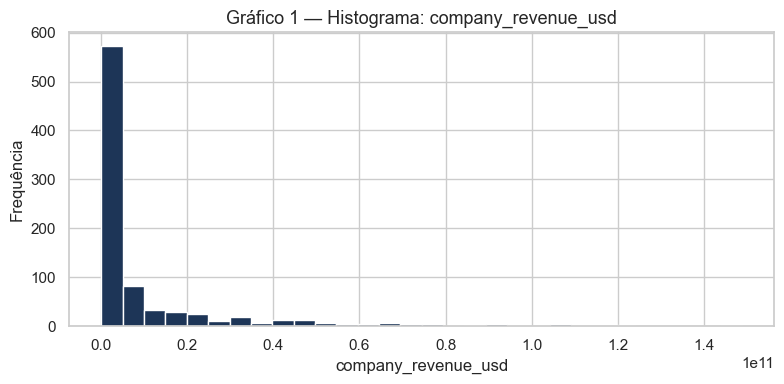

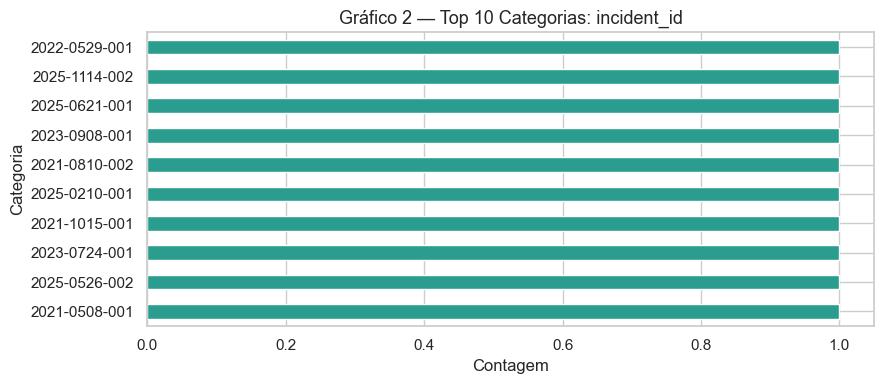

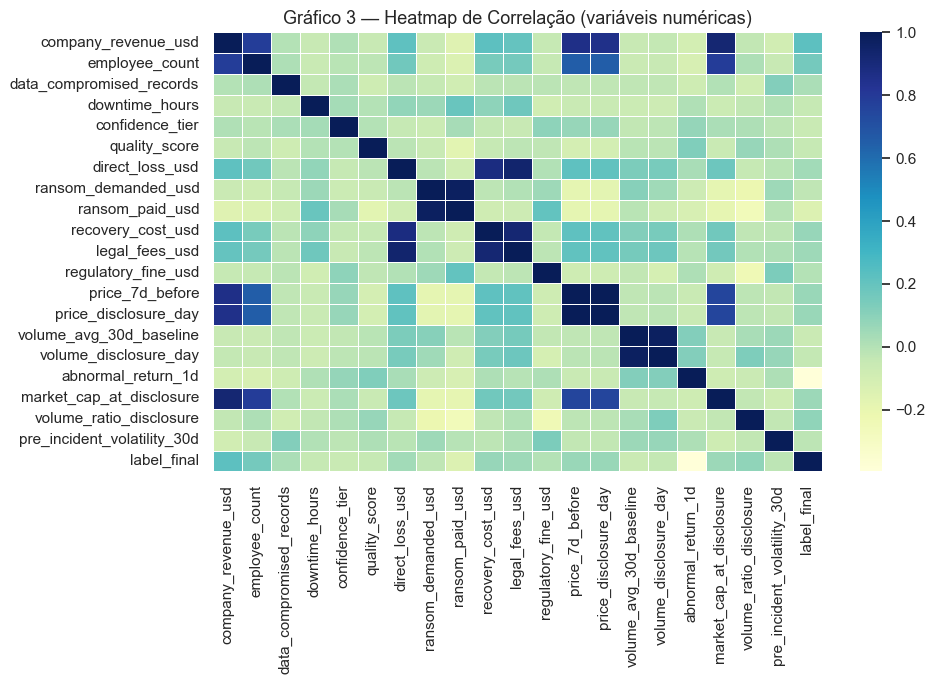

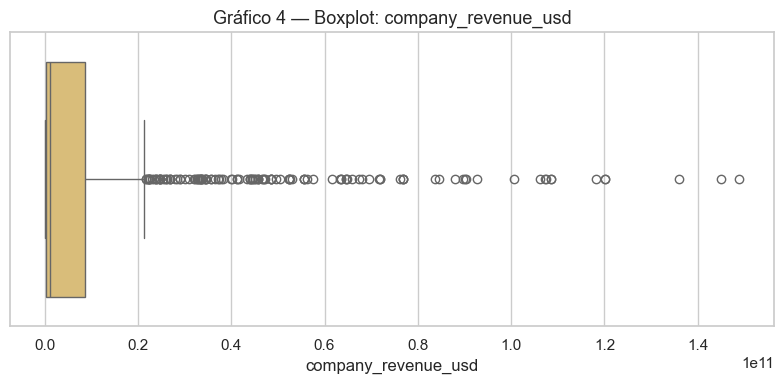

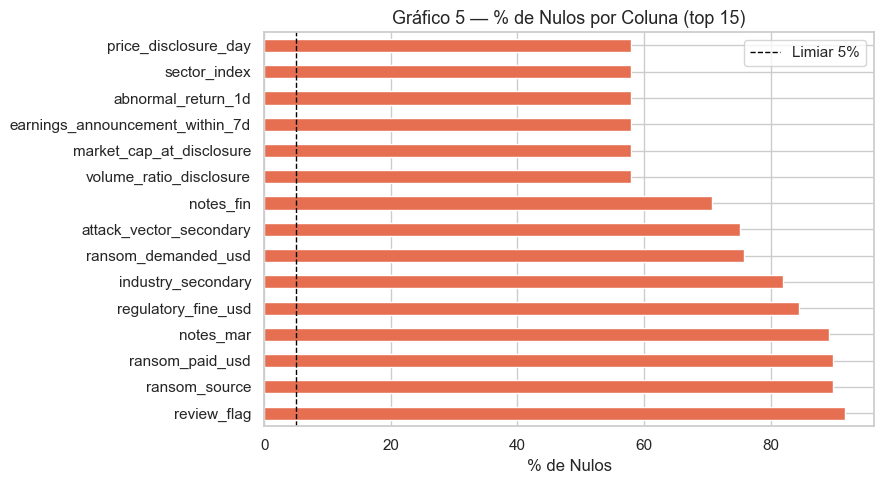


✅ 5 gráfico(s) gerado(s):
  - data_lake\eda_notebook\01_histograma_numerica.png
  - data_lake\eda_notebook\02_top_categorias.png
  - data_lake\eda_notebook\03_heatmap_correlacao.png
  - data_lake\eda_notebook\04_boxplot_numerica.png
  - data_lake\eda_notebook\05_nulos_por_coluna.png


In [12]:
eda_output = DATA_LAKE_ROOT / "eda_notebook"
eda_output.mkdir(parents=True, exist_ok=True)
generated_plots = []

if num_cols:
    plt.figure(figsize=(8, 4))
    df[num_cols[0]].dropna().plot(kind="hist", bins=30, color="#1D3557", edgecolor="white")
    plt.title(f"Gráfico 1 — Histograma: {num_cols[0]}", fontsize=13)
    plt.xlabel(num_cols[0])
    plt.ylabel("Frequência")
    plt.tight_layout()
    p1 = eda_output / "01_histograma_numerica.png"
    plt.savefig(p1, dpi=140)
    plt.show()
    generated_plots.append(p1)

cat_for_plot = cat_cols[0] if cat_cols else "_origem_tabela"
plt.figure(figsize=(9, 4))
df[cat_for_plot].astype(str).value_counts().head(10).sort_values().plot(
    kind="barh", color="#2A9D8F"
)
plt.title(f"Gráfico 2 — Top 10 Categorias: {cat_for_plot}", fontsize=13)
plt.xlabel("Contagem")
plt.ylabel("Categoria")
plt.tight_layout()
p2 = eda_output / "02_top_categorias.png"
plt.savefig(p2, dpi=140)
plt.show()
generated_plots.append(p2)

if len(num_cols) >= 2:
    plt.figure(figsize=(10, 7))
    corr = df[num_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap="YlGnBu", annot=False, linewidths=0.5)
    plt.title("Gráfico 3 — Heatmap de Correlação (variáveis numéricas)", fontsize=13)
    plt.tight_layout()
    p3 = eda_output / "03_heatmap_correlacao.png"
    plt.savefig(p3, dpi=140)
    plt.show()
    generated_plots.append(p3)

if num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[num_cols[0]], color="#E9C46A")
    plt.title(f"Gráfico 4 — Boxplot: {num_cols[0]}", fontsize=13)
    plt.tight_layout()
    p4 = eda_output / "04_boxplot_numerica.png"
    plt.savefig(p4, dpi=140)
    plt.show()
    generated_plots.append(p4)

null_series = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
null_series.plot(kind="barh", color="#E76F51")
plt.title("Gráfico 5 — % de Nulos por Coluna (top 15)", fontsize=13)
plt.xlabel("% de Nulos")
plt.axvline(x=5, color="black", linestyle="--", linewidth=1, label="Limiar 5%")
plt.legend()
plt.tight_layout()
p5 = eda_output / "05_nulos_por_coluna.png"
plt.savefig(p5, dpi=140)
plt.show()
generated_plots.append(p5)

print(f"\n✅ {len(generated_plots)} gráfico(s) gerado(s):")
for p in generated_plots:
    print(f"  - {p}")

## 4.2 Testes Estatísticos e Correlações

In [13]:
stat_results = {}

if stats is not None and len(num_cols) >= 2:
    a = df[num_cols[0]].dropna()
    b = df[num_cols[1]].dropna()
    if len(a) > 2 and len(b) > 2:
        n = min(len(a), len(b))
        corr_val, pval = stats.pearsonr(a.iloc[:n], b.iloc[:n])
        stat_results["pearson"] = {
            "col_a": num_cols[0], "col_b": num_cols[1],
            "corr": float(corr_val), "p_value": float(pval)
        }
        print(f"Correlação de Pearson entre '{num_cols[0]}' e '{num_cols[1]}':")
        print(f"  r = {corr_val:.4f} | p-value = {pval:.4f}")

if stats is not None and "label_final" in df.columns and num_cols:
    g0 = df.loc[df["label_final"] == 0, num_cols[0]].dropna()
    g1 = df.loc[df["label_final"] == 1, num_cols[0]].dropna()
    if len(g0) > 1 and len(g1) > 1:
        t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
        stat_results["t_test_label"] = {
            "feature": num_cols[0], "t_stat": float(t_stat), "p_value": float(p_val)
        }
        print(f"\nTeste t (label=0 vs label=1) para '{num_cols[0]}':")
        print(f"  t = {t_stat:.4f} | p-value = {p_val:.4f}")

stat_results

Correlação de Pearson entre 'company_revenue_usd' e 'employee_count':
  r = 0.7827 | p-value = 0.0000

Teste t (label=0 vs label=1) para 'company_revenue_usd':
  t = -6.1221 | p-value = 0.0000


{'pearson': {'col_a': 'company_revenue_usd',
  'col_b': 'employee_count',
  'corr': 0.7827322872563462,
  'p_value': 7.765316884700422e-177},
 't_test_label': {'feature': 'company_revenue_usd',
  't_stat': -6.122113197599238,
  'p_value': 1.767597559084439e-09}}

## 4.3 Modelagem Baseline (Opcional)

In [14]:
model_metrics = {}
model_ready = False

if (
    train_test_split is not None
    and "label_final" in df.columns
    and df["label_final"].notna().any()
):
    model_df = df[df["label_final"].isin([0, 1])].copy()
    if len(model_df) >= 20:
        y = model_df["label_final"].astype(int)
        X = model_df.drop(columns=["label_final"], errors="ignore")
        num_features = [c for c in X.select_dtypes(include=["number"]).columns if not c.startswith("_")]
        cat_features = [c for c in X.select_dtypes(include=["object", "category", "string"]).columns if not c.startswith("_")]
        preprocessor = ColumnTransformer(transformers=[
            ("num", SimpleImputer(strategy="median"), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_features),
        ], remainder="drop")
        clf = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=500))])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        model_metrics = {
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "f1": float(f1_score(y_test, y_pred, zero_division=0)),
            "classification_report": classification_report(y_test, y_pred, zero_division=0),
        }
        model_ready = True

print(f"Modelo treinado: {model_ready}")

if model_metrics:
    print(f"Accuracy : {model_metrics['accuracy']:.4f}")
    print(f"F1 Score : {model_metrics['f1']:.4f}")
    print("\nClassification Report:")
    print(model_metrics["classification_report"])
else:
    print("Sem métricas de modelagem: verifique se há label_final válido e scikit-learn instalado.")

TypeError: boolean value of NA is ambiguous

## 4.4 Exportar Artefatos e Relatório Final

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

prepared_path = eda_output / f"silver_preparado_{timestamp}.csv"
df.to_csv(prepared_path, index=False)

metrics_payload = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "shape": {"rows": int(len(df)), "cols": int(len(df.columns))},
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "stat_results": stat_results,
    "model_metrics": {
        k: v for k, v in model_metrics.items() if k != "classification_report"
    },
    "plots": [str(p) for p in generated_plots],
}
metrics_path = eda_output / "eda_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

report_lines = [
    "# Relatório EDA — Pipeline Bronze → Silver",
    f"- Gerado em: {metrics_payload['generated_at']}",
    f"- Linhas: {len(df)}",
    f"- Colunas: {len(df.columns)}",
    f"- Datasets unificados: incidents_master + financial_impact + market_impact",
    "\n## Gráficos Gerados",
] + [f"- {Path(p).name}" for p in metrics_payload["plots"]] + [
    "\n## Observações e Próximos Passos",
    "- Validar possíveis outliers nos boxplots/histogramas.",
    "- Revisar distribuição do label para equilíbrio de classes.",
    "- Priorizar variáveis com correlação consistente para baseline de ML.",
    "- Definir estratégia formal de imputação e tratamento de outliers.",
    "- Testar modelos baseline adicionais (árvore, random forest, XGBoost).",
]
report_path = eda_output / "eda_report_notebook.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Artefatos exportados:")
print(f"  - {prepared_path}")
print(f"  - {metrics_path}")
print(f"  - {report_path}")

print(f"\nResumo EDA Final:")
print(f"  - Linhas     : {len(df)}")
print(f"  - Colunas    : {len(df.columns)}")
print(f"  - Numéricas  : {len(num_cols)}")
print(f"  - Categóricas: {len(cat_cols)}")
print(f"  - Gráficos   : {len(generated_plots)}")

✅ Artefatos exportados:
  - data_lake\eda_notebook\silver_preparado_20260415_184722.csv
  - data_lake\eda_notebook\eda_metrics.json
  - data_lake\eda_notebook\eda_report_notebook.md

📋 Resumo EDA Final:
  - Linhas     : 358
  - Colunas    : 34
  - Numéricas  : 24
  - Categóricas: 7
  - Gráficos   : 5


---
## Interpretação e Próximos Passos

**Interpretações sugeridas:**
- Observe colunas com maior percentual de nulos para decidir entre imputação ou descarte.
- Compare histogramas e boxplots para detectar assimetria e outliers.
- Analise categorias dominantes para evitar vieses na modelagem.
- Verifique correlações fortes para orientar seleção de variáveis.
- Revise a distribuição de `label_final` para avaliar balanceamento de classes.

**Próximos passos para ML:**
1. Definir estratégia formal de imputação e tratamento de outliers.
2. Criar conjunto de features com versionamento.
3. Testar modelos baseline adicionais (árvore de decisão, Random Forest, XGBoost).
4. Aplicar validação cruzada e comparação de métricas por experimento.

---
*Pipeline gerado automaticamente — Projeto Prático de Engenharia de Dados*